# Mutual Fund Performance Analysis
Analysing 68 funds from the Moneycontrol screener export.  
Goals:
- Identify funds with **high 10-year returns** *and* **stable performance** across all time frames
- Visualise distribution by **Category**, **Crisil Rating**, and **AUM**

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#c9d1d9",
    "axes.facecolor": "#c9d1d9",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#0d1117",
    "xtick.color": "#0d1117",
    "ytick.color": "#0d1117",
    "grid.color": "#21262d",
    "legend.facecolor": "#99bcec",
    "legend.edgecolor": "#c5daf3",
})

PALETTE = [
    "#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
    "#79c0ff","#56d364","#ff7b72","#bc8cff","#e3b341",
    "#1f6feb","#238636",
]
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load and Inspect the Data

In [2]:
TSV_PATH = Path("../mutualfunds/all_funds_moneycontrol.tsv")
df = pd.read_csv(TSV_PATH, sep="\t")

# ── numeric coercion ─────────────────────────────────────────────────────────
RETURN_COLS = ["1W", "1M", "3M", "6M", "YTD", "1Y", "2Y", "3Y", "5Y", "10Y"]

# returns are stored as "32%" strings — strip % and convert to float
for c in RETURN_COLS:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

df["AuM (Cr)"]      = pd.to_numeric(df["AuM (Cr)"], errors="coerce")
df["Crisil Rating"] = pd.to_numeric(df["Crisil Rating"], errors="coerce")

# ── short readable name ──────────────────────────────────────────────────────
df["Short Name"] = (
    df["Scheme Name"]
    .str.replace(r" - Direct Plan.*", "", regex=True)
    .str.replace(r" - Growth.*", "", regex=True)
    .str.strip()
)

print(f"Dataset: {df.shape[0]} funds × {df.shape[1]} columns")
print(f"\nReturn columns  : {RETURN_COLS}")
print(f"Categories      : {sorted(df['Category Name'].unique())}")
print(f"Crisil Ratings  : {sorted(df['Crisil Rating'].dropna().unique())}")
print(f"AuM range (Cr)  : {df['AuM (Cr)'].min():,.0f} – {df['AuM (Cr)'].max():,.0f}")
df.head()


Dataset: 924 funds × 16 columns

Return columns  : ['1W', '1M', '3M', '6M', 'YTD', '1Y', '2Y', '3Y', '5Y', '10Y']
Categories      : ['Contra', 'Dividend Yield', 'ELSS (Tax Savings)', 'Equity - Consumption', 'Equity - ESG', 'Equity - Infrastructure', 'Equity - Other', 'Flexi Cap', 'Focused Fund', 'Global - Other', 'Index Funds', 'Large & Mid-Cap', 'Large-Cap', 'Mid-Cap', 'Multi-Cap', 'Sector - Energy', 'Sector - FMCG', 'Sector - Financial Services', 'Sector - Healthcare', 'Sector - Technology', 'Small-Cap', 'Value']
Crisil Ratings  : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
AuM range (Cr)  : nan – nan


,Scheme Name,Plan,Category Name,Crisil Rating,AuM (Cr),1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,Short Name
0,Mirae Asset NYSE FANG+ ETF FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,-0.62,0.96,-7.76,-7.15,-7.28,31.35,33.82,47.94,NaN,NaN,Mirae Asset NYSE FANG+ ETF FoF Dir Gr
1,DSP Wld Gld Mng Ovrs Eq Omni FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,3.89,-20.89,3.94,24.36,4.16,111.94,79.04,47.18,27.71,17.93,DSP Wld Gld Mng Ovrs Eq Omni FoF Dir Gr
2,Mirae Asset S&P 500 Top50 ETF FoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,1.24,-3.42,-6.24,-0.46,-4.86,37.17,29.71,34.00,NaN,NaN,Mirae Asset S&P 500 Top50 ETF FoF Dir Gr
3,ICICI Pru Strat Mt & En EqFoF Dir Gr,Direct Plan,Global - Other,NaN,NaN,5.18,1.44,29.54,43.43,30.72,81.72,46.15,32.90,NaN,NaN,ICICI Pru Strat Mt & En EqFoF Dir Gr
4,SBI PSU Dir Gr,Direct Plan,Equity - Other,NaN,NaN,-0.68,-11.83,-1.92,1.72,-3.33,10.45,8.78,31.15,26.72,15.70,SBI PSU Dir Gr


## 3. Calculate 10-Year Return Rankings

In [3]:
top10yr = (
    df[["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)", "10Y"]]
    .dropna(subset=["10Y"])
    .sort_values("10Y", ascending=False)
    .reset_index(drop=True)
)
top10yr.index += 1
top10yr["10Y (%)"] = top10yr["10Y"].round(2)
top10yr.drop(columns="10Y", inplace=True)
top10yr.index.name = "Rank"

print(f"Funds with 10Y data: {len(top10yr)}")
print(f"Median 10Y return  : {top10yr['10Y (%)'].median():.1f}%")
print(f"Top 10Y return     : {top10yr['10Y (%)'].max():.1f}% — {top10yr.iloc[0]['Short Name']}")
top10yr.head(20)

Funds with 10Y data: 274
Median 10Y return  : 14.3%
Top 10Y return     : 20.8% — Nippon India Small Cap Dir Gr


,Short Name,Category Name,Crisil Rating,AuM (Cr),10Y (%)
Rank,,,,,
1,Nippon India Small Cap Dir Gr,Small-Cap,5.0,NaN,20.80
2,Quant ELSS Tax Saver Dir Gr,ELSS (Tax Savings),5.0,NaN,20.06
3,DSP Nat Res & New Enrgy Dir Gr,Equity - Other,NaN,NaN,19.94
4,DSP Wld Mng Ovrs Eq Omni FoF Dir Gr,Global - Other,NaN,NaN,19.26
5,Quant Flexi Cap Dir Gr,Flexi Cap,5.0,NaN,19.15
6,Edelweiss Mid Cap Dir Gr,Mid-Cap,5.0,NaN,19.12
7,Bank of India Manfactrg &Infra Dir Gr,Equity - Infrastructure,5.0,NaN,19.06
8,Invesco India Mid Cap Dir Gr,Mid-Cap,5.0,NaN,18.96
9,Nippon India Growth Mid Cap Dir Gr,Mid-Cap,5.0,NaN,18.93


## 4. Assess Return Stability Across Time Frames

Stability is measured via the **Coefficient of Variation (CV)** across the longer-horizon return columns (1Y, 3Y, 5Y, 10Y).  
A lower CV means the fund has been consistently strong *relative to its own mean*, not just peaking in one period.

$$CV = \frac{\sigma}{\mu} \times 100$$

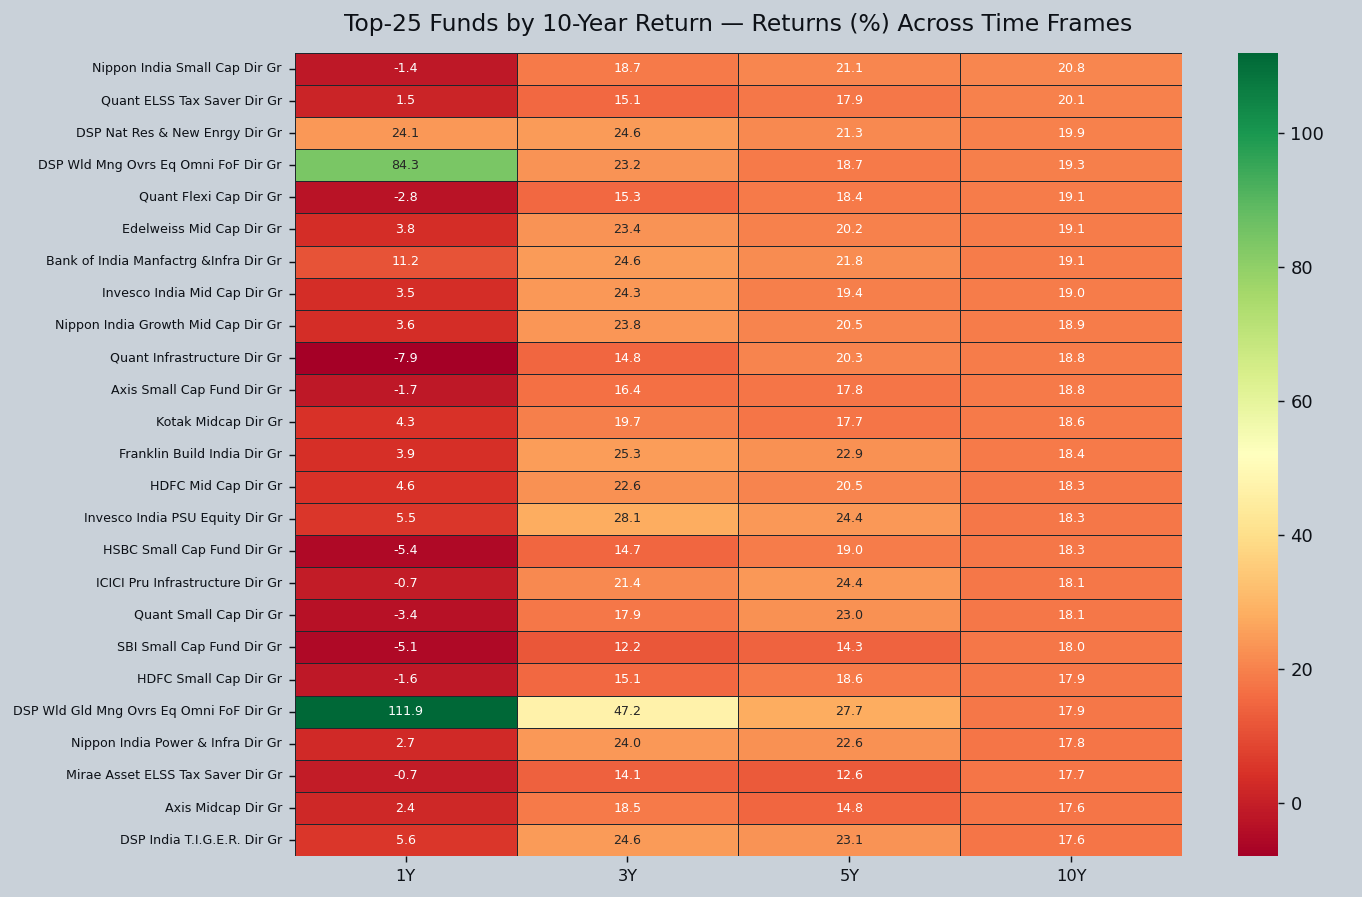


Funds in stability analysis: 274


In [4]:
# Use longer-horizon cols only — short periods (1W/1M) are noise
STABILITY_COLS = ["1Y", "3Y", "5Y", "10Y"]

sub = df[["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)"] + STABILITY_COLS].copy()
sub = sub.dropna(subset=STABILITY_COLS)   # keep only funds with full history

# Returns are already in % points from preprocessing
sub["mean_return"] = sub[STABILITY_COLS].mean(axis=1)
sub["std_return"]  = sub[STABILITY_COLS].std(axis=1)
sub["CV"]          = (sub["std_return"] / sub["mean_return"].abs()) * 100

# Heatmap: top 25 by 10Y return, columns = time-frame returns
top25 = sub.nlargest(25, "10Y").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
heat_data = top25.set_index("Short Name")[STABILITY_COLS]
sns.heatmap(
    heat_data,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.4, linecolor="#21262d",
    ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"label": "Return (%)"},
)
ax.set_title("Top-25 Funds by 10-Year Return — Returns (%) Across Time Frames", pad=12, fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

print(f"\nFunds in stability analysis: {len(sub)}")

## 5. Identify Top Performing Stable Funds

A **composite score** combines:
- **10-year return rank** (higher is better)
- **CV rank** (lower CV = lower rank number = better stability)

$$\text{Composite Score} = \text{Rank}_{10Y\,Return} + \text{Rank}_{CV}$$

Lower composite score → fund is both high-returning *and* stable.

In [5]:
scored = sub.copy()
scored["rank_10Y"] = scored["10Y"].rank(ascending=False)
scored["rank_CV"]  = scored["CV"].rank(ascending=True)   # low CV = good
scored["composite"] = scored["rank_10Y"] + scored["rank_CV"]
scored = scored.sort_values("composite").reset_index(drop=True)
scored.index += 1
scored.index.name = "Composite Rank"

display_cols = ["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)",
                "10Y", "mean_return", "std_return", "CV", "composite"]
out = scored[display_cols].head(20).copy()
out.rename(columns={
    "10Y": "10Y Return (%)",
    "mean_return": "Mean Return (%)",
    "std_return": "StdDev (%)",
    "CV": "CV (%)",
    "composite": "Score (lower=better)",
    "AuM (Cr)": "AuM (Cr)",
}, inplace=True)
for col in ["10Y Return (%)", "Mean Return (%)", "StdDev (%)", "CV (%)"]:
    out[col] = out[col].round(2)
out["Score (lower=better)"] = out["Score (lower=better)"].round(1)
out["AuM (Cr)"] = out["AuM (Cr)"].map("{:,.0f}".format)
out

,Short Name,Category Name,Crisil Rating,AuM (Cr),10Y Return (%),Mean Return (%),StdDev (%),CV (%),Score (lower=better)
Composite Rank,,,,,,,,,
1,DSP Nat Res & New Enrgy Dir Gr,Equity - Other,NaN,nan,19.94,22.48,2.21,9.85,4.0
2,Bank of India Manfactrg &Infra Dir Gr,Equity - Infrastructure,5.0,nan,19.06,19.13,5.77,30.15,18.0
3,SBI Comma Dir Gr,Equity - Other,NaN,nan,17.22,15.95,3.42,21.44,36.0
4,Kotak Midcap Dir Gr,Mid-Cap,4.0,nan,18.64,15.07,7.24,48.05,41.0
5,ICICI Pru MidCap Dir Gr,Mid-Cap,4.0,nan,17.13,17.91,4.81,26.83,44.0
6,Edelweiss Mid Cap Dir Gr,Mid-Cap,5.0,nan,19.12,16.63,8.77,52.73,47.0
7,HSBC Midcap Dir Gr,Mid-Cap,4.0,nan,17.24,16.58,5.99,36.12,47.0
8,HDFC Mid Cap Dir Gr,Mid-Cap,5.0,nan,18.31,16.49,8.14,49.39,51.0
9,Nippon India Growth Mid Cap Dir Gr,Mid-Cap,5.0,nan,18.93,16.72,8.97,53.63,52.0


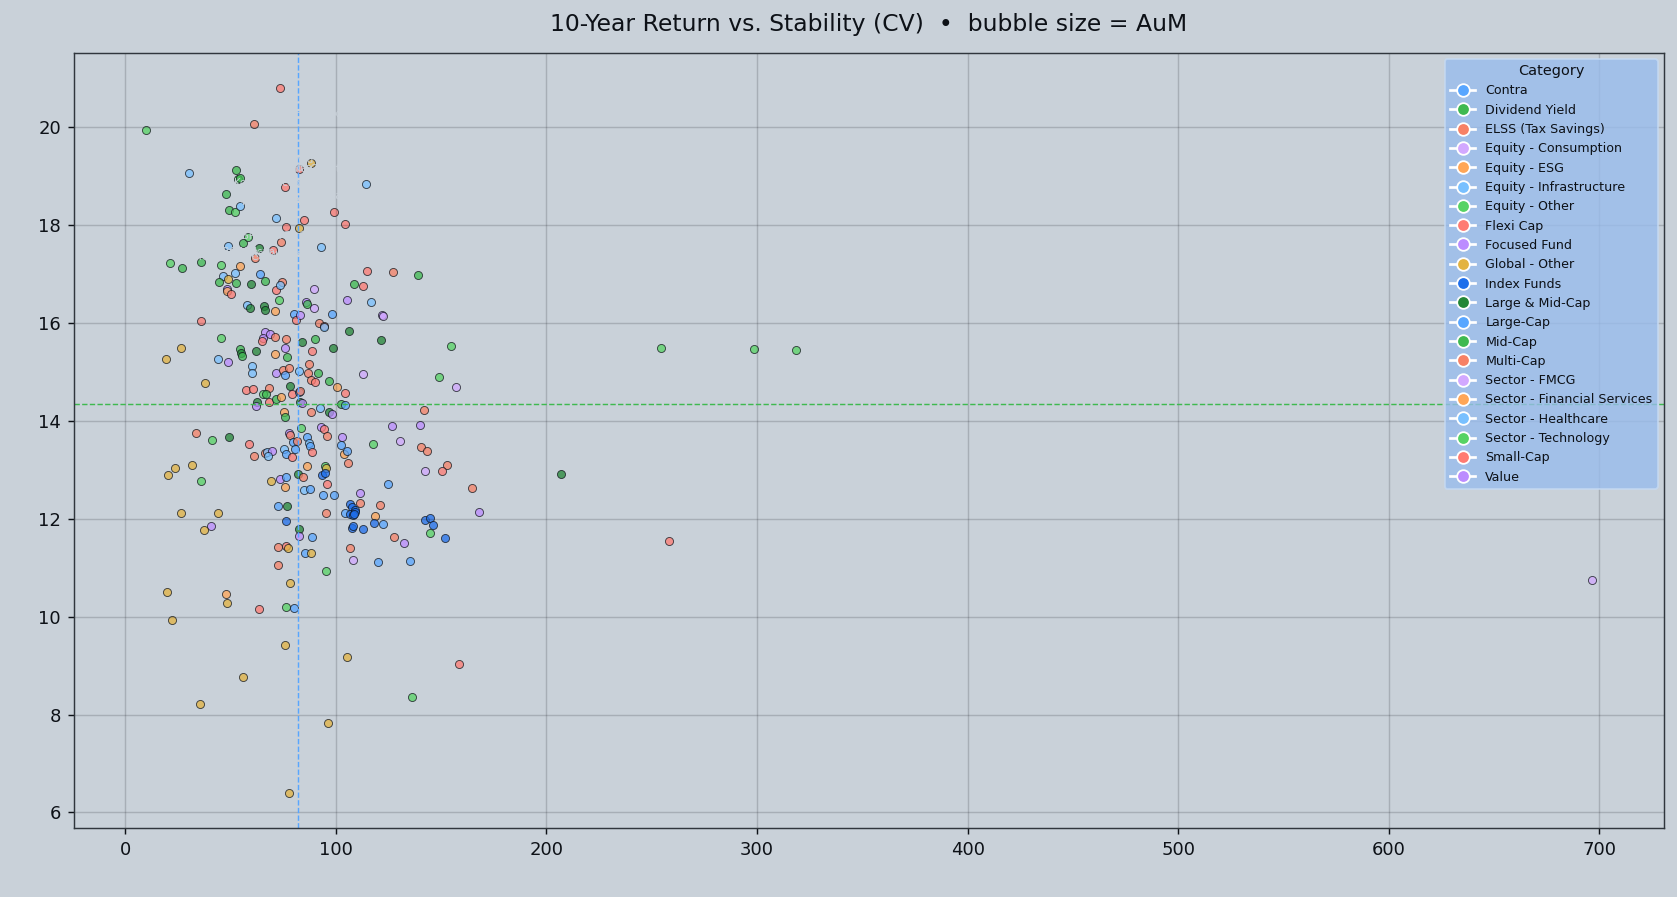

In [6]:
# ── Bubble chart: 10Y return vs CV, sized by AuM ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

cat_list = sorted(scored["Category Name"].unique())
cat_colors = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(cat_list)}

for _, row in scored.iterrows():
    ax.scatter(
        row["CV"], row["10Y"],
        s=max(20, row["AuM (Cr)"] / 800),
        color=cat_colors[row["Category Name"]],
        alpha=0.75, edgecolors="#0d1117", linewidth=0.5,
    )

# label top-15 composite
for _, row in scored.head(15).iterrows():
    label = row["Short Name"].split()[0:3]
    ax.annotate(
        " ".join(label),
        xy=(row["CV"], row["10Y"]),
        fontsize=5.5,
        color="#c9d1d9",
        xytext=(4, 4), textcoords="offset points",
    )

# legend for categories
handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=v, markersize=7, label=k)
    for k, v in cat_colors.items()
]
ax.legend(handles=handles, title="Category", fontsize=7, title_fontsize=8,
          loc="upper right")

ax.set_xlabel("Coefficient of Variation (%) — lower = more stable", fontsize=10)
ax.set_ylabel("10-Year Return (%)", fontsize=10)
ax.set_title("10-Year Return vs. Stability (CV)  •  bubble size = AuM", fontsize=13, pad=12)
ax.axvline(scored["CV"].median(), color="#58a6ff", linestyle="--", linewidth=0.8,
           label=f"Median CV ({scored['CV'].median():.0f}%)")
ax.axhline(scored["10Y"].median(), color="#3fb950", linestyle="--", linewidth=0.8,
           label=f"Median 10Y ({scored['10Y'].median():.1f}%)")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Category-Wise Distribution Pie Chart

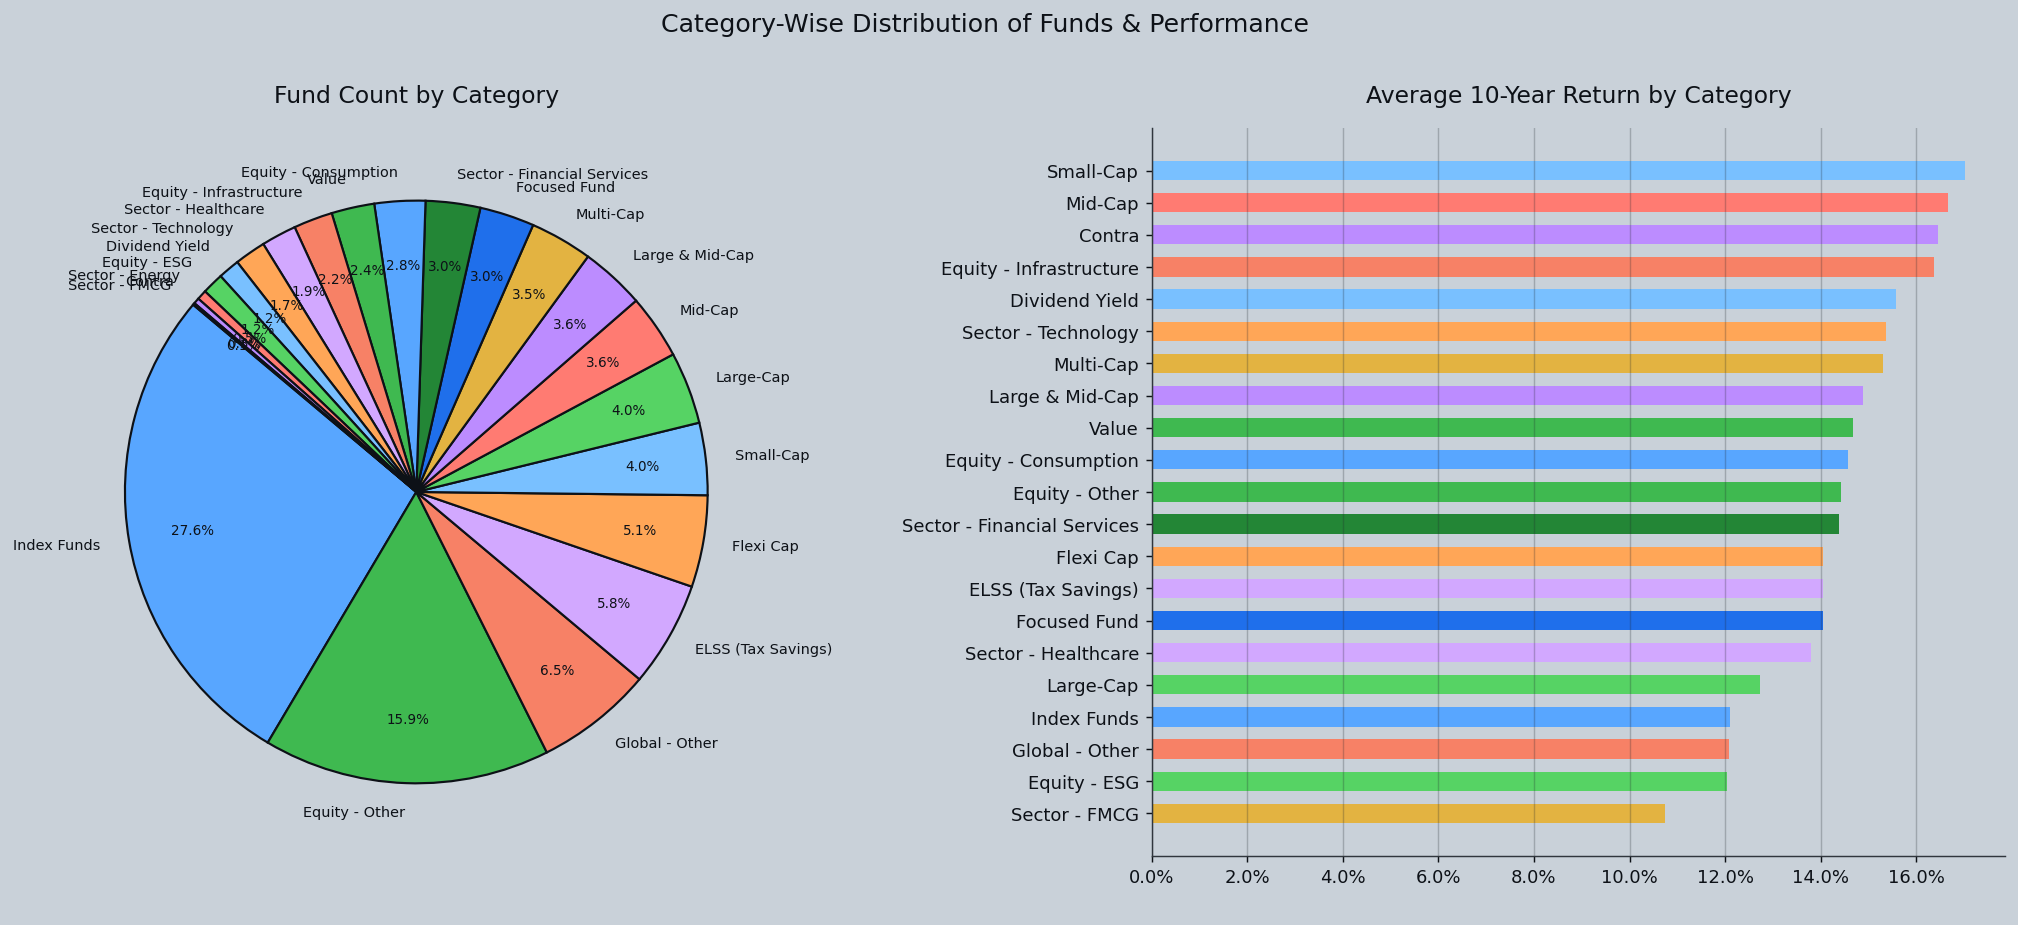

In [7]:
cat_counts = df["Category Name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: fund count ────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    cat_counts,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETTE[:len(cat_counts)],
    pctdistance=0.78,
    wedgeprops={"linewidth": 1.2, "edgecolor": "#0d1117"},
)
for t in texts: t.set_fontsize(8)
for at in autotexts: at.set_fontsize(7.5); at.set_color("#0d1117")
axes[0].set_title("Fund Count by Category", fontsize=13, pad=14)

# ── Right: average 10Y return per category ──────────────────────────────────
cat_10y = df.groupby("Category Name")["10Y"].mean().dropna().sort_values(ascending=False)
bar_colors = [PALETTE[list(cat_counts.index).index(c) % len(PALETTE)] for c in cat_10y.index]

axes[1].barh(cat_10y.index[::-1], cat_10y.values[::-1], color=bar_colors[::-1], height=0.6)
axes[1].xaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
axes[1].set_xlabel("Avg 10-Year CAGR", fontsize=10)
axes[1].set_title("Average 10-Year Return by Category", fontsize=13, pad=14)
axes[1].grid(axis="x", alpha=0.25)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)

plt.suptitle("Category-Wise Distribution of Funds & Performance", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Crisil Rating Distribution Pie Chart

> **Note:** The screener exports **Crisil Rank** (1–5 stars), not Morningstar ratings. Both use a 5-star scale and serve the same purpose: rating funds within their peer category on a risk-adjusted basis. Crisil 5 = top quintile.

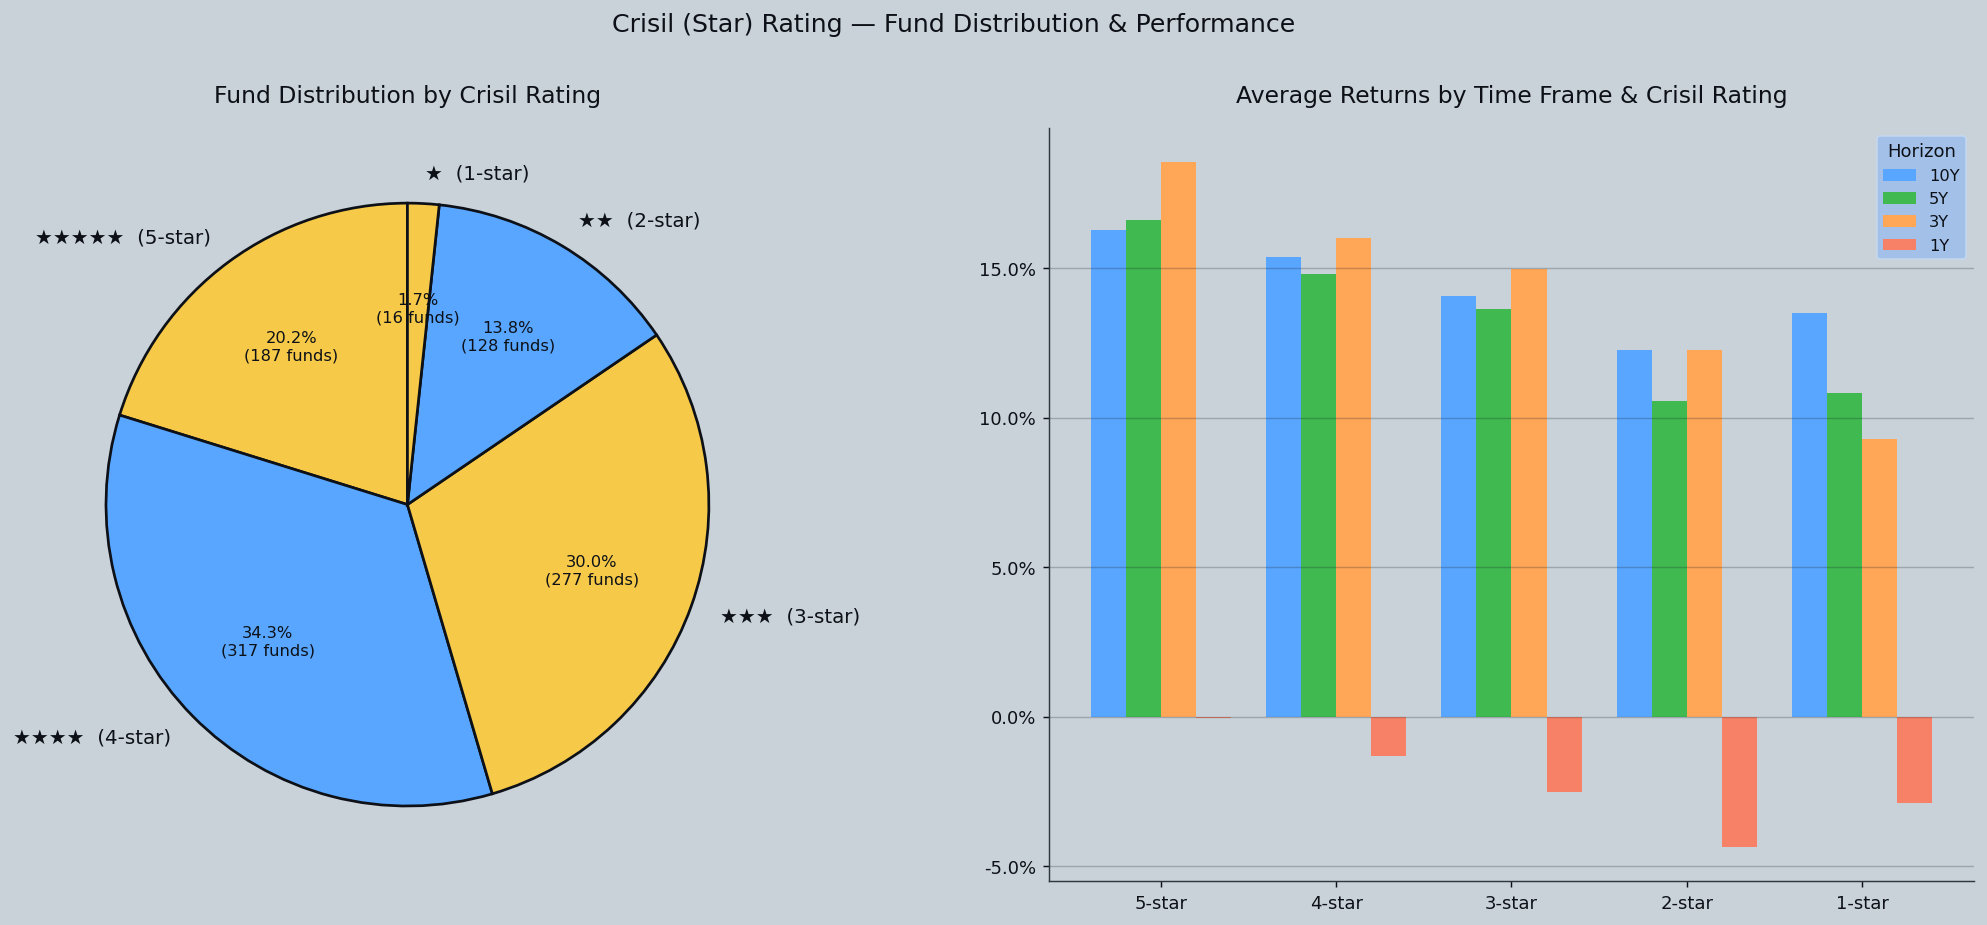

In [8]:
rating_counts = df["Crisil Rating"].value_counts().sort_index(ascending=False)
star_labels = [f"{'★' * int(r)}  ({int(r)}-star)" for r in rating_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: pie ───────────────────────────────────────────────────────────────
star_colors = ["#f7c948", "#58a6ff"]   # gold for 5, blue for 4
wedges, texts, autotexts = axes[0].pie(
    rating_counts,
    labels=star_labels,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * len(df) / 100))} funds)",
    startangle=90,
    colors=star_colors[:len(rating_counts)],
    wedgeprops={"linewidth": 1.5, "edgecolor": "#0d1117"},
    pctdistance=0.65,
)
for t in texts: t.set_fontsize(11)
for at in autotexts: at.set_fontsize(9); at.set_color("#0d1117")
axes[0].set_title("Fund Distribution by Crisil Rating", fontsize=13, pad=14)

# ── Right: avg 10Y return per rating ────────────────────────────────────────
rating_perf = (
    df.groupby("Crisil Rating")[["10Y", "5Y", "3Y", "1Y"]]
    .mean()
    .dropna()
    .sort_index(ascending=False)
)
x = np.arange(len(rating_perf))
width = 0.2
tf_cols  = ["10Y", "5Y", "3Y", "1Y"]
tf_colors = ["#58a6ff", "#3fb950", "#ffa657", "#f78166"]

for i, (col, col_c) in enumerate(zip(tf_cols, tf_colors)):
    axes[1].bar(x + i * width, rating_perf[col], width, label=col, color=col_c)

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([f"{int(r)}-star" for r in rating_perf.index])
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
axes[1].set_ylabel("Avg CAGR (%)", fontsize=10)
axes[1].set_title("Average Returns by Time Frame & Crisil Rating", fontsize=13, pad=14)
axes[1].legend(title="Horizon", fontsize=9)
axes[1].grid(axis="y", alpha=0.25)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)

plt.suptitle("Crisil (Star) Rating — Fund Distribution & Performance", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. AUM Distribution by Category

Using fallback AuM source: top_funds_moneycontrol.tsv (68 funds)


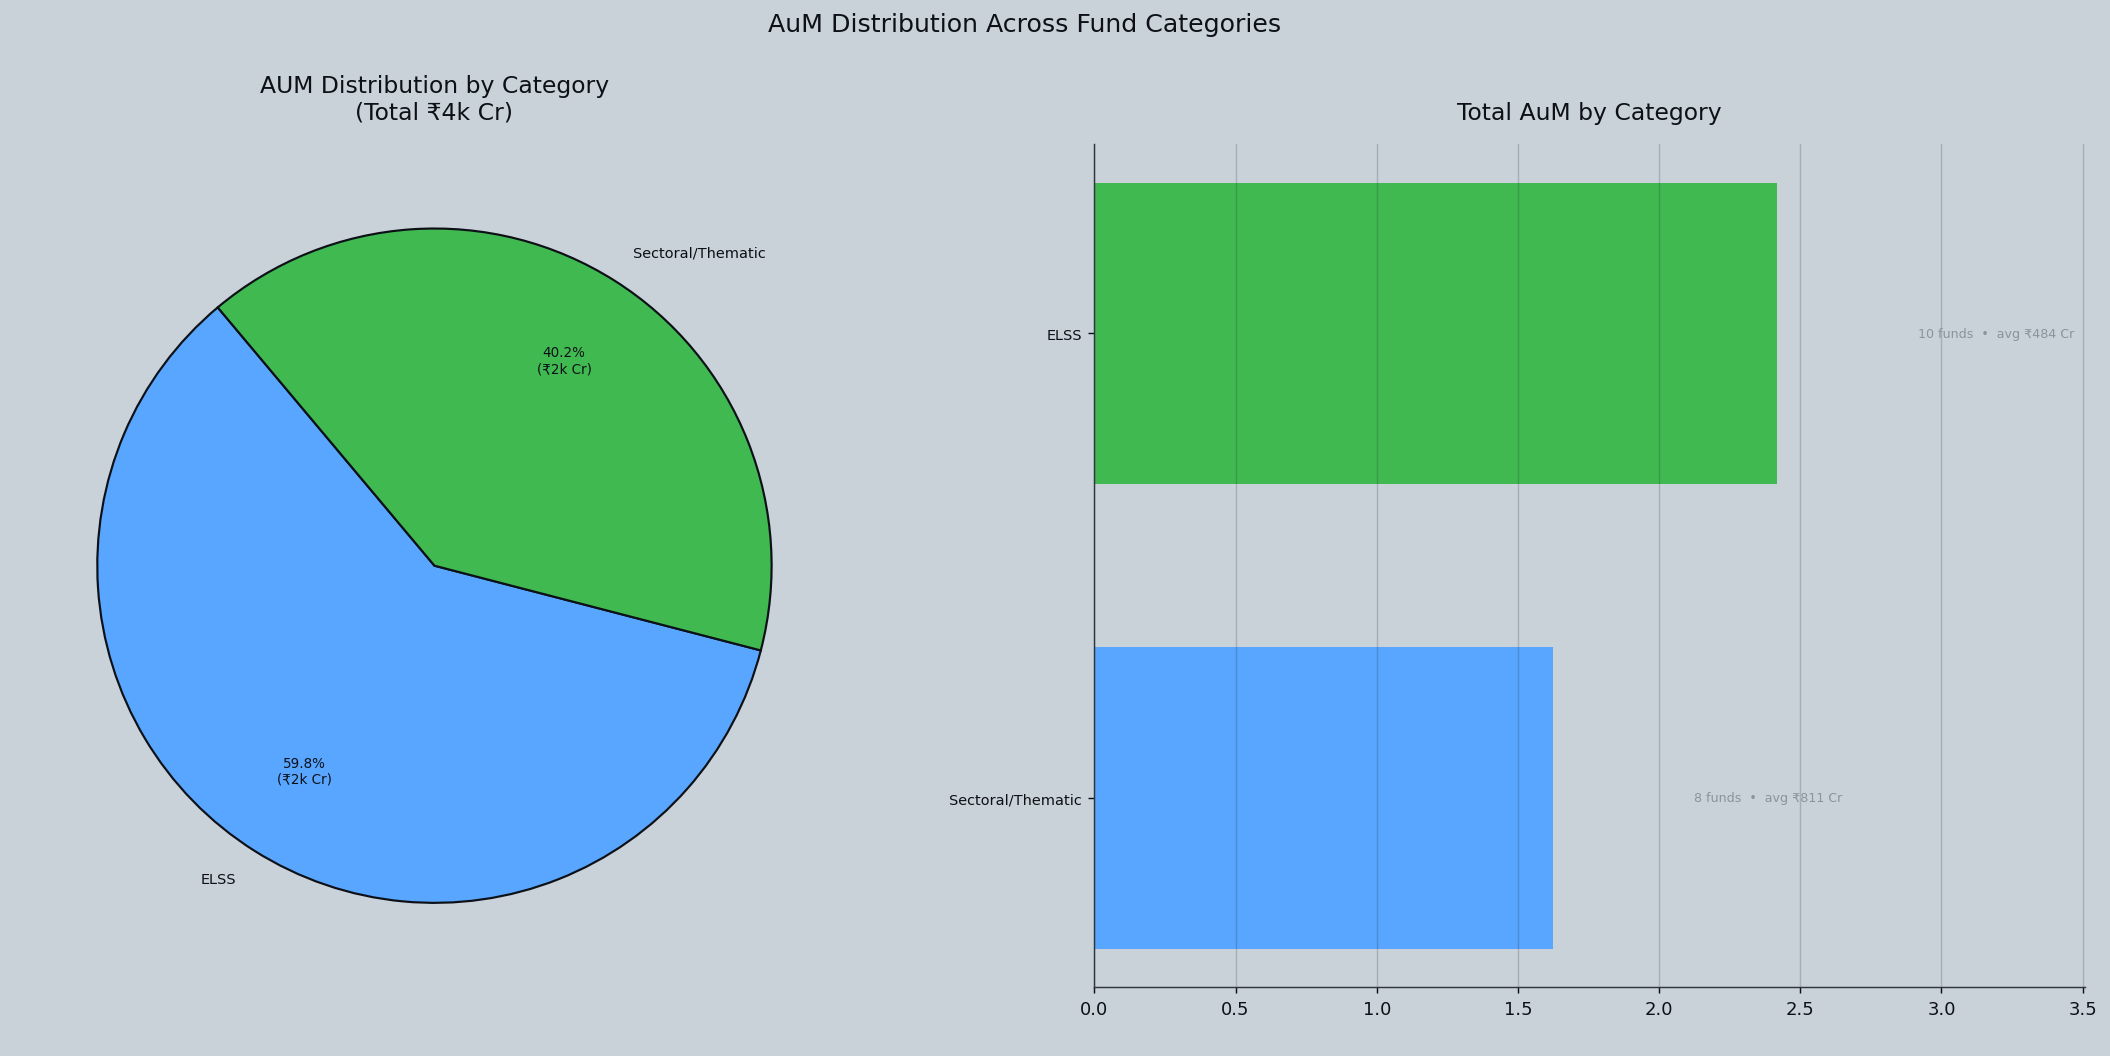


AuM summary (₹ Cr):
Category Name
ELSS                 2,419
Sectoral/Thematic    1,623


In [9]:
# Prefer current dataframe, but if AuM is fully missing fallback to the top-funds export
a_df = df.copy()
if "AuM (Cr)" not in a_df.columns or a_df["AuM (Cr)"].notna().sum() == 0:
    fallback_path = Path("../mutualfunds/top_funds_moneycontrol.tsv")
    if fallback_path.exists():
        fb = pd.read_csv(fallback_path, sep="\t")
        if "AuM (Cr)" in fb.columns:
            fb["AuM (Cr)"] = pd.to_numeric(fb["AuM (Cr)"], errors="coerce")
            if fb["AuM (Cr)"].notna().sum() > 0:
                a_df = fb
                print(f"Using fallback AuM source: {fallback_path.name} ({len(a_df)} funds)")

# Build a clean category-level AUM series for plotting
aum_by_cat = (
    a_df.groupby("Category Name")["AuM (Cr)"]
    .sum(min_count=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)
aum_by_cat = aum_by_cat[aum_by_cat > 0]
total_aum = aum_by_cat.sum()

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

if len(aum_by_cat) == 0 or not np.isfinite(total_aum) or total_aum <= 0:
    axes[0].axis("off")
    axes[0].text(
        0.5, 0.5,
        "No valid AuM data available\nfor category distribution",
        ha="center", va="center", fontsize=12, color="#8b949e",
        transform=axes[0].transAxes,
    )
    axes[0].set_title("AUM Distribution by Category", fontsize=13, pad=14)
else:
    aum_colors = [PALETTE[i % len(PALETTE)] for i in range(len(aum_by_cat))]

    # ── Left: AUM pie ────────────────────────────────────────────────────────
    def aum_fmt(pct):
        val = pct / 100 * total_aum
        return f"{pct:.1f}%\n(₹{val/1e3:.0f}k Cr)" if pct > 4 else ""

    wedges, texts, autotexts = axes[0].pie(
        aum_by_cat.values,
        labels=aum_by_cat.index,
        autopct=aum_fmt,
        startangle=130,
        colors=aum_colors,
        pctdistance=0.72,
        wedgeprops={"linewidth": 1.2, "edgecolor": "#0d1117"},
    )
    for t in texts:
        t.set_fontsize(8)
    for at in autotexts:
        at.set_fontsize(7.5)
        at.set_color("#0d1117")
    axes[0].set_title(f"AUM Distribution by Category\n(Total ₹{total_aum/1e3:,.0f}k Cr)", fontsize=13, pad=14)

# ── Right: stacked bar — fund count & avg AuM per fund ─────────────────────
cat_stats = (
    a_df.groupby("Category Name").agg(
        fund_count=("Scheme Name", "count"),
        avg_aum=("AuM (Cr)", "mean"),
        total_aum=("AuM (Cr)", "sum"),
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["total_aum", "avg_aum"])
    .sort_values("total_aum", ascending=True)
)
cat_stats = cat_stats[cat_stats["total_aum"] > 0]

if len(cat_stats) == 0:
    axes[1].axis("off")
    axes[1].text(
        0.5, 0.5,
        "No valid AuM totals available\nfor category bar chart",
        ha="center", va="center", fontsize=12, color="#8b949e",
        transform=axes[1].transAxes,
    )
    axes[1].set_title("Total AuM by Category", fontsize=13, pad=14)
else:
    y_pos = np.arange(len(cat_stats))
    bar_c = [PALETTE[i % len(PALETTE)] for i in range(len(cat_stats))]

    bars = axes[1].barh(y_pos, cat_stats["total_aum"] / 1e3, color=bar_c, height=0.65)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(cat_stats.index, fontsize=8)
    axes[1].set_xlabel("Total AuM (₹ '000 Cr)", fontsize=10)
    axes[1].set_title("Total AuM by Category", fontsize=13, pad=14)

    # annotate fund count
    for bar, (_, row) in zip(bars, cat_stats.iterrows()):
        axes[1].text(
            bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{int(row['fund_count'])} funds  •  avg ₹{row['avg_aum']:,.0f} Cr",
            va="center", fontsize=7, color="#8b949e",
        )

    axes[1].grid(axis="x", alpha=0.2)
    for spine in ["top", "right"]:
        axes[1].spines[spine].set_visible(False)
    axes[1].set_xlim(0, cat_stats["total_aum"].max() / 1e3 * 1.45)

plt.suptitle("AuM Distribution Across Fund Categories", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nAuM summary (₹ Cr):")
if len(aum_by_cat) == 0:
    print("No valid AuM values found in input data.")
else:
    print(aum_by_cat.map("{:,.0f}".format).to_string())

---

### 📊 Core Market-Cap Categories

**1. Large Cap**

* Invest ≥80% in top 100 companies (by market cap)
* Stable, lower volatility, moderate returns
* Best for: conservative investors

**2. Mid Cap**

* Invest ≥65% in companies ranked 101–250
* Higher growth potential, higher risk
* Best for: long-term investors with moderate risk

**3. Small Cap**

* Invest ≥65% beyond top 250 companies
* Very high growth + very high volatility
* Best for: aggressive, long-term investors

---

### ⚖️ Blended Market-Cap Categories

**4. Large & Mid Cap**

* ≥35% each in large + mid caps
* Balanced between stability and growth
* More structured than flexi/multicap

**5. Multi Cap**

* Must invest ≥25% each in large, mid, small caps
* Strict allocation across all segments
* Diversified but less flexible

**6. Flexi Cap**

* ≥65% in equities, no cap restrictions
* Fund manager decides allocation dynamically
* Most flexible diversified category

---

### 🎯 Strategy-Based Categories

**7. Focused Fund**

* Max 30 stocks
* Concentrated bets → higher risk/reward
* Depends heavily on fund manager skill

**8. ELSS (Equity Linked Savings Scheme)**

* Tax-saving under Section 80C of Income Tax Act
* 3-year lock-in
* Equity exposure ≥80%
* Combines tax benefit + growth

---

### 🧭 Thematic & Style-Based

**9. Sectoral / Thematic**

* Invest in a specific sector/theme (e.g., IT, pharma, infra)
* Very high risk (low diversification)
* Cyclical performance

**10. Value Fund**

* Invest in undervalued stocks (cheap vs intrinsic value)
* Long-term re-rating potential
* Slower but steady strategy

**11. Contra Fund**

* Contrarian approach (buy unpopular/out-of-favor stocks)
* Requires patience; works when market sentiment reverses
* Similar to value but more sentiment-driven

---

### ⚡ Quick Comparison Snapshot

| Category    | Flexibility | Risk Level | Diversification |
| ----------- | ----------- | ---------- | --------------- |
| Large Cap   | Low         | Low        | High            |
| Mid Cap     | Medium      | Medium     | Medium          |
| Small Cap   | Low         | High       | Medium          |
| Large & Mid | Medium      | Medium     | High            |
| Multi Cap   | Low         | Medium     | High            |
| Flexi Cap   | High        | Medium     | High            |
| Focused     | High        | High       | Low             |
| ELSS        | Medium      | Medium     | High            |
| Sectoral    | Low         | Very High  | Very Low        |
| Value       | Medium      | Medium     | Medium          |
| Contra      | Medium      | Medium     | Medium          |

---